In [1]:
# ============================================================
# WEEK 6 FINAL DATA ANALYTICS PROJECT
# Initial Dataset Inspection
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ============================================================
# STEP 2 — LOAD RAW DATASET
# ============================================================

from pathlib import Path

# Identify the project folder
current_path = Path.cwd()

if current_path.name == "notebooks":
    PROJECT_ROOT = current_path.parent
else:
    PROJECT_ROOT = current_path

# Define raw dataset path
raw_path = PROJECT_ROOT / "data" / "raw" / "ecommerce_sales_raw.csv"

# Load dataset
df = pd.read_csv(raw_path)

print("Raw dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Raw dataset loaded successfully.
Rows: 2,510
Columns: 26


In [3]:
# ============================================================
# STEP 3 — FIRST LOOK AT THE DATA
# ============================================================

print("First 10 records of the raw dataset:")
display(df.head(10))

First 10 records of the raw dataset:


,Order_ID,Order_Date,Customer_ID,Customer_Segment,Region,City,Sales_Channel,Product_ID,Product_Name,Category,Quantity,Unit_Price,Discount_Percent,Gross_Sales,Discount_Amount,Shipping_Cost,Payment_Fee,Cost_of_Goods,Return_Flag,Return_Quantity,Return_Amount,Net_Revenue,Profit,Profit_Margin,Payment_Method,Order_Status
0,ORD00001,2024-01-05,C0466,Consumer,West,Mumbai,Website,P013,Coffee Maker,Home & Kitchen,3,4050.06,10.0,12150.18,1215.02,78.75,209.81,7650,False,0,0.0,10935.16,2996.60,27.40,Credit Card,Delivered
1,ORD00002,2024-03-18,C0216,Consumer,South,Chennai,Website,P008,Fitness Band,Sports,1,2040.22,5.0,2040.22,102.01,65.15,63.59,1200,False,0,0.0,1938.21,609.47,31.44,Debit Card,Delivered
2,ORD00003,2024-04-18,C0146,Consumer,West,Ahmedabad,Mobile App,P013,Coffee Maker,Home & Kitchen,1,3932.40,5.0,3932.40,196.62,73.74,69.98,2550,False,0,0.0,3735.78,1042.06,27.89,UPI,Delivered
3,ORD00004,2024-08-30,C0543,Consumer,North,Chandigarh,Marketplace,P017,Notebook Set,Stationery,5,571.69,15.0,2858.45,428.77,81.90,72.22,1300,False,0,0.0,2429.68,975.56,40.15,Debit Card,Delivered
4,ORD00005,2025-07-03,C0139,Consumer,East,Kolkata,Mobile App,P014,Air Fryer,Home & Kitchen,2,5775.10,10.0,11550.20,1155.02,62.41,332.80,7000,False,0,0.0,10395.18,2999.97,28.86,Credit Card,Delivered
5,ORD00006,2025-04-03,C0137,Consumer,West,Ahmedabad,Website,P019,Planner,Stationery,3,737.09,5.0,2211.27,110.56,119.16,50.95,960,False,0,0.0,2100.71,970.60,46.20,Debit Card,Delivered
6,ORD00007,2025-10-26,C0145,Consumer,East,Patna,Mobile App,P014,Air Fryer,Home & Kitchen,1,5625.28,10.0,5625.28,562.53,47.04,133.65,3500,False,0,0.0,5062.75,1382.06,27.30,Net Banking,Delivered
7,ORD00008,2024-06-07,C0228,Consumer,North,Chandigarh,Website,P001,Wireless Headphones,Electronics,2,1917.63,5.0,3835.26,191.76,137.02,123.68,2100,False,0,0.0,3643.50,1282.80,35.21,Credit Card,Delivered
8,ORD00009,2025-09-14,C0460,Consumer,West,Surat,Mobile App,P004,Laptop Stand,Electronics,3,1424.72,5.0,4274.16,213.71,105.40,79.37,2550,False,0,0.0,4060.45,1325.68,32.65,UPI,Delivered
9,ORD00010,2024-07-20,C0436,Corporate,South,Chennai,Website,P013,Coffee Maker,Home & Kitchen,1,4388.49,0.0,4388.49,0.00,84.66,111.04,2550,False,0,0.0,4388.49,1642.79,37.43,Credit Card,Delivered


In [5]:
# ============================================================
# STEP 4 — COLUMN AND DATA TYPE INSPECTION
# ============================================================

print("Dataset Information")
print("=" * 60)

print(f"Total Rows    : {df.shape[0]:,}")
print(f"Total Columns : {df.shape[1]}")

print("\nColumn Names and Data Types")
print("=" * 60)

for column in df.columns:
    print(f"{column:20} -> {df[column].dtype}")

Dataset Information
Total Rows    : 2,510
Total Columns : 26

Column Names and Data Types
Order_ID             -> str
Order_Date           -> str
Customer_ID          -> str
Customer_Segment     -> str
Region               -> str
City                 -> str
Sales_Channel        -> str
Product_ID           -> str
Product_Name         -> str
Category             -> str
Quantity             -> int64
Unit_Price           -> float64
Discount_Percent     -> float64
Gross_Sales          -> float64
Discount_Amount      -> float64
Shipping_Cost        -> float64
Payment_Fee          -> float64
Cost_of_Goods        -> int64
Return_Flag          -> bool
Return_Quantity      -> int64
Return_Amount        -> float64
Net_Revenue          -> float64
Profit               -> float64
Profit_Margin        -> float64
Payment_Method       -> str
Order_Status         -> str


In [6]:
# ============================================================
# STEP 5 — MISSING VALUE ANALYSIS
# ============================================================

missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing_Count": missing_values,
    "Missing_Percentage": (missing_values / len(df) * 100).round(2)
})

missing_summary = missing_summary[
    missing_summary["Missing_Count"] > 0
].sort_values("Missing_Count", ascending=False)

print("Missing Value Analysis")
print("=" * 60)

if missing_summary.empty:
    print("No missing values found.")
else:
    display(missing_summary)

Missing Value Analysis


,Missing_Count,Missing_Percentage
Customer_Segment,8,0.32
City,7,0.28
Discount_Percent,5,0.20
Payment_Method,5,0.20


In [7]:
# ============================================================
# STEP 6 — DUPLICATE RECORD ANALYSIS
# ============================================================

duplicate_count = df.duplicated().sum()

print("Duplicate Record Analysis")
print("=" * 60)
print(f"Duplicate rows found: {duplicate_count}")

if duplicate_count > 0:
    print("\nSample duplicate records:")
    display(df[df.duplicated(keep=False)].sort_values("Order_ID").head(10))
else:
    print("No duplicate records found.")

Duplicate Record Analysis
Duplicate rows found: 10

Sample duplicate records:


,Order_ID,Order_Date,Customer_ID,Customer_Segment,Region,City,Sales_Channel,Product_ID,Product_Name,Category,Quantity,Unit_Price,Discount_Percent,Gross_Sales,Discount_Amount,Shipping_Cost,Payment_Fee,Cost_of_Goods,Return_Flag,Return_Quantity,Return_Amount,Net_Revenue,Profit,Profit_Margin,Payment_Method,Order_Status
497,ORD00498,2025-05-02,C0382,Corporate,West,Pune,Website,P007,Yoga Mat,Sports,6,1112.30,0.0,6673.80,0.00,239.01,149.32,3900,True,2,2224.6,4449.20,160.87,3.62,Net Banking,Returned
2508,ORD00498,2025-05-02,C0382,Corporate,West,Pune,Website,P007,Yoga Mat,Sports,6,1112.30,0.0,6673.80,0.00,239.01,149.32,3900,True,2,2224.6,4449.20,160.87,3.62,Net Banking,Returned
668,ORD00669,2024-11-03,C0367,Home Office,North,Jaipur,Website,P003,Bluetooth Speaker,Electronics,2,2176.56,15.0,4353.12,652.97,102.65,101.03,2600,False,0,0.0,3700.15,896.47,24.23,Credit Card,Delivered
2505,ORD00669,2024-11-03,C0367,Home Office,North,Jaipur,Website,P003,Bluetooth Speaker,Electronics,2,2176.56,15.0,4353.12,652.97,102.65,101.03,2600,False,0,0.0,3700.15,896.47,24.23,Credit Card,Delivered
1064,ORD01065,2024-08-26,C0442,Home Office,West,Surat,Mobile App,P004,Laptop Stand,Electronics,1,1500.77,10.0,1500.77,150.08,233.18,23.26,850,False,0,0.0,1350.69,244.25,18.08,Debit Card,Delivered
2502,ORD01065,2024-08-26,C0442,Home Office,West,Surat,Mobile App,P004,Laptop Stand,Electronics,1,1500.77,10.0,1500.77,150.08,233.18,23.26,850,False,0,0.0,1350.69,244.25,18.08,Debit Card,Delivered
1114,ORD01115,2025-08-06,C0103,Consumer,West,Surat,Mobile App,P009,Office Backpack,Accessories,5,1724.66,5.0,8623.30,431.16,112.80,220.18,5000,False,0,0.0,8192.14,2859.16,34.90,Credit Card,Delivered
2501,ORD01115,2025-08-06,C0103,Consumer,West,Surat,Mobile App,P009,Office Backpack,Accessories,5,1724.66,5.0,8623.30,431.16,112.80,220.18,5000,False,0,0.0,8192.14,2859.16,34.90,Credit Card,Delivered
1447,ORD01448,2025-03-07,C0456,Consumer,West,Pune,Website,P020,Study Table Organizer,Stationery,2,1038.72,10.0,2077.44,207.74,188.70,53.70,900,False,0,0.0,1869.70,727.30,38.90,UPI,Delivered
2500,ORD01448,2025-03-07,C0456,Consumer,West,Pune,Website,P020,Study Table Organizer,Stationery,2,1038.72,10.0,2077.44,207.74,188.70,53.70,900,False,0,0.0,1869.70,727.30,38.90,UPI,Delivered


In [8]:
# ============================================================
# STEP 7 — INVALID VALUE ANALYSIS
# ============================================================

print("Invalid Value Analysis")
print("=" * 60)

# Check negative or zero quantities
invalid_quantity = df[df["Quantity"] <= 0]

# Check zero or negative unit prices
invalid_price = df[df["Unit_Price"] <= 0]

# Check discounts outside the valid 0–100% range
invalid_discount = df[
    (df["Discount_Percent"] < 0) |
    (df["Discount_Percent"] > 100)
]

# Convert dates temporarily for validation
order_dates = pd.to_datetime(df["Order_Date"], errors="coerce")

# Check invalid dates and future dates
invalid_dates = df[order_dates.isna()]
future_dates = df[order_dates > pd.Timestamp.today().normalize()]

print(f"Invalid Quantity records       : {len(invalid_quantity)}")
print(f"Invalid Unit Price records     : {len(invalid_price)}")
print(f"Invalid Discount records       : {len(invalid_discount)}")
print(f"Invalid Date records           : {len(invalid_dates)}")
print(f"Future-dated records           : {len(future_dates)}")

Invalid Value Analysis
Invalid Quantity records       : 5
Invalid Unit Price records     : 5
Invalid Discount records       : 5
Invalid Date records           : 0
Future-dated records           : 3


In [9]:
# ============================================================
# STEP 8 — INSPECT INVALID RECORDS
# ============================================================

print("1. Invalid Quantity Records")
print("=" * 60)
display(df[df["Quantity"] <= 0][
    ["Order_ID", "Order_Date", "Product_Name", "Quantity",
     "Unit_Price", "Gross_Sales", "Profit"]
])

print("\n2. Invalid Unit Price Records")
print("=" * 60)
display(df[df["Unit_Price"] <= 0][
    ["Order_ID", "Order_Date", "Product_Name", "Quantity",
     "Unit_Price", "Gross_Sales", "Profit"]
])

print("\n3. Invalid Discount Records")
print("=" * 60)
display(df[
    (df["Discount_Percent"] < 0) |
    (df["Discount_Percent"] > 100)
][
    ["Order_ID", "Order_Date", "Product_Name",
     "Discount_Percent", "Gross_Sales", "Profit"]
])

print("\n4. Future-Dated Records")
print("=" * 60)
display(df[order_dates > pd.Timestamp.today().normalize()][
    ["Order_ID", "Order_Date", "Customer_ID",
     "Product_Name", "Category", "Net_Revenue", "Profit"]
])

1. Invalid Quantity Records


,Order_ID,Order_Date,Product_Name,Quantity,Unit_Price,Gross_Sales,Profit
187,ORD00188,2024-09-02,Running Shoes,-2,3262.17,3262.17,723.59
211,ORD00212,2024-11-24,Laptop Stand,-2,1575.15,3150.30,1120.60
1014,ORD01015,2025-07-13,Fitness Band,-2,2143.87,2143.87,746.67
1523,ORD01524,2024-01-14,Office Backpack,-2,1852.73,1852.73,342.75
1699,ORD01700,2025-07-20,Travel Bag,-2,2605.81,2605.81,638.13



2. Invalid Unit Price Records


,Order_ID,Order_Date,Product_Name,Quantity,Unit_Price,Gross_Sales,Profit
41,ORD00042,2025-03-28,Study Table Organizer,2,-500.0,2006.70,872.86
270,ORD00271,2024-06-26,Laptop Stand,2,-500.0,2806.98,-557.16
1711,ORD01712,2024-03-15,Wireless Headphones,1,-500.0,1918.96,680.05
1944,ORD01945,2025-09-23,Sunglasses,3,-500.0,4484.19,1551.66
2082,ORD02083,2025-08-28,Smart Watch,2,-500.0,6469.22,1748.12



3. Invalid Discount Records


,Order_ID,Order_Date,Product_Name,Discount_Percent,Gross_Sales,Profit
846,ORD00847,2025-03-04,Smart Watch,150.0,6405.98,1369.86
1333,ORD01334,2025-03-23,Office Backpack,150.0,1835.83,367.73
1365,ORD01366,2025-03-17,Fitness Band,150.0,2074.48,661.35
1670,ORD01671,2025-04-02,Leather Wallet,150.0,5560.60,2008.88
1866,ORD01867,2024-01-29,Smart Watch,150.0,5941.86,1606.95



4. Future-Dated Records


,Order_ID,Order_Date,Customer_ID,Product_Name,Category,Net_Revenue,Profit
346,ORD00347,2027-06-15,C0291,Office Backpack,Accessories,1522.17,-2808.11
676,ORD00677,2027-06-15,C0437,Fitness Band,Sports,1960.80,674.47
2106,ORD02107,2027-06-15,C0066,Leather Wallet,Accessories,1058.72,429.06


In [10]:
# ============================================================
# STEP 9 — DATA CLEANING AND PREPARATION
# ============================================================

# Create a separate copy so the original raw dataset remains unchanged
cleaned_df = df.copy()

print("Starting data cleaning...")
print("=" * 60)

# ------------------------------------------------------------
# 1. Convert Order_Date from text to datetime
# ------------------------------------------------------------

cleaned_df["Order_Date"] = pd.to_datetime(
    cleaned_df["Order_Date"],
    errors="coerce"
)

# ------------------------------------------------------------
# 2. Remove exact duplicate records
# ------------------------------------------------------------

before_duplicates = len(cleaned_df)

cleaned_df = cleaned_df.drop_duplicates()

duplicates_removed = before_duplicates - len(cleaned_df)

print(f"Duplicate rows removed      : {duplicates_removed}")

# ------------------------------------------------------------
# 3. Remove invalid numerical records
# ------------------------------------------------------------

before_invalid = len(cleaned_df)

cleaned_df = cleaned_df[
    (cleaned_df["Quantity"] > 0) &
    (cleaned_df["Unit_Price"] > 0) &
    (cleaned_df["Discount_Percent"].between(0, 100))
].copy()

invalid_records_removed = before_invalid - len(cleaned_df)

print(f"Invalid numerical rows removed: {invalid_records_removed}")

# ------------------------------------------------------------
# 4. Remove future-dated records
# ------------------------------------------------------------

today = pd.Timestamp.today().normalize()

before_future = len(cleaned_df)

cleaned_df = cleaned_df[
    cleaned_df["Order_Date"] <= today
].copy()

future_records_removed = before_future - len(cleaned_df)

print(f"Future-dated rows removed    : {future_records_removed}")

# ------------------------------------------------------------
# 5. Handle missing Customer_Segment
# ------------------------------------------------------------

customer_segment_mode = cleaned_df["Customer_Segment"].mode()[0]

cleaned_df["Customer_Segment"] = cleaned_df["Customer_Segment"].fillna(
    customer_segment_mode
)

# ------------------------------------------------------------
# 6. Handle missing City
# ------------------------------------------------------------

# Fill missing cities using the most common city within each region
city_by_region = (
    cleaned_df.groupby("Region")["City"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)

missing_city_mask = cleaned_df["City"].isna()

cleaned_df.loc[missing_city_mask, "City"] = (
    cleaned_df.loc[missing_city_mask, "Region"]
    .map(city_by_region)
)

# Fallback in case any city is still missing
cleaned_df["City"] = cleaned_df["City"].fillna(
    cleaned_df["City"].mode()[0]
)

# ------------------------------------------------------------
# 7. Handle missing Discount_Percent
# ------------------------------------------------------------

discount_median = cleaned_df["Discount_Percent"].median()

cleaned_df["Discount_Percent"] = cleaned_df["Discount_Percent"].fillna(
    discount_median
)

# ------------------------------------------------------------
# 8. Handle missing Payment_Method
# ------------------------------------------------------------

payment_method_mode = cleaned_df["Payment_Method"].mode()[0]

cleaned_df["Payment_Method"] = cleaned_df["Payment_Method"].fillna(
    payment_method_mode
)

# ------------------------------------------------------------
# 9. Reset index after cleaning
# ------------------------------------------------------------

cleaned_df = cleaned_df.reset_index(drop=True)

# ------------------------------------------------------------
# Cleaning summary
# ------------------------------------------------------------

print("\nCleaning completed successfully.")
print("=" * 60)

print(f"Original rows                 : {len(df):,}")
print(f"Cleaned rows                  : {len(cleaned_df):,}")
print(f"Total rows removed            : {len(df) - len(cleaned_df):,}")

print("\nRemaining missing values:")
print(cleaned_df.isnull().sum().sum())

print(f"Remaining duplicate rows      : {cleaned_df.duplicated().sum()}")

print("\nCleaned dataset shape:")
print(cleaned_df.shape)

Starting data cleaning...
Duplicate rows removed      : 10
Invalid numerical rows removed: 20
Future-dated rows removed    : 3

Cleaning completed successfully.
Original rows                 : 2,510
Cleaned rows                  : 2,477
Total rows removed            : 33

Remaining missing values:
0
Remaining duplicate rows      : 0

Cleaned dataset shape:
(2477, 26)


In [11]:
# ============================================================
# STEP 10 — VERIFY CLEANED DATASET
# ============================================================

print("FINAL DATA QUALITY VERIFICATION")
print("=" * 60)

# Missing values
missing_after = cleaned_df.isnull().sum().sum()

# Duplicate rows
duplicates_after = cleaned_df.duplicated().sum()

# Invalid quantities
invalid_quantity_after = (cleaned_df["Quantity"] <= 0).sum()

# Invalid unit prices
invalid_price_after = (cleaned_df["Unit_Price"] <= 0).sum()

# Invalid discounts
invalid_discount_after = (
    (cleaned_df["Discount_Percent"] < 0) |
    (cleaned_df["Discount_Percent"] > 100)
).sum()

# Invalid dates
invalid_dates_after = cleaned_df["Order_Date"].isna().sum()

# Future dates
future_dates_after = (
    cleaned_df["Order_Date"] > pd.Timestamp.today().normalize()
).sum()

# Display verification results
verification = pd.DataFrame({
    "Quality_Check": [
        "Missing values",
        "Duplicate rows",
        "Invalid quantities",
        "Invalid unit prices",
        "Invalid discounts",
        "Invalid dates",
        "Future-dated orders"
    ],
    "Remaining_Records": [
        missing_after,
        duplicates_after,
        invalid_quantity_after,
        invalid_price_after,
        invalid_discount_after,
        invalid_dates_after,
        future_dates_after
    ]
})

display(verification)

# Overall result
if verification["Remaining_Records"].sum() == 0:
    print("\n✓ CLEANED DATASET PASSED ALL QUALITY CHECKS")
else:
    print("\n⚠ Some data-quality issues still remain.")

FINAL DATA QUALITY VERIFICATION


,Quality_Check,Remaining_Records
0,Missing values,0
1,Duplicate rows,0
2,Invalid quantities,0
3,Invalid unit prices,0
4,Invalid discounts,0
5,Invalid dates,0
6,Future-dated orders,0



✓ CLEANED DATASET PASSED ALL QUALITY CHECKS


In [12]:
# ============================================================
# STEP 11 — SAVE CLEANED DATASET
# ============================================================

from pathlib import Path

# Create cleaned-data folder
cleaned_folder = PROJECT_ROOT / "data" / "cleaned"
cleaned_folder.mkdir(parents=True, exist_ok=True)

# Define output path
cleaned_path = cleaned_folder / "ecommerce_sales_cleaned.csv"

# Save cleaned dataset
cleaned_df.to_csv(cleaned_path, index=False)

print("Cleaned dataset saved successfully.")
print(f"Location: {cleaned_path}")
print(f"Rows saved: {len(cleaned_df):,}")
print(f"Columns saved: {len(cleaned_df.columns)}")

Cleaned dataset saved successfully.
Location: c:\Users\mehta\OneDrive\Week6_Final_Data_Analytics_Project\data\cleaned\ecommerce_sales_cleaned.csv
Rows saved: 2,477
Columns saved: 26


In [13]:
# ============================================================
# STEP 12 — DESCRIPTIVE STATISTICS
# ============================================================

print("DESCRIPTIVE STATISTICS")
print("=" * 60)

# Summary statistics for numerical columns
descriptive_stats = cleaned_df.describe().T

# Round numerical results for readability
descriptive_stats = descriptive_stats.round(2)

display(descriptive_stats)

DESCRIPTIVE STATISTICS


,count,mean,min,25%,50%,75%,max,std
Order_Date,2477,2024-12-26 21:59:04.771901,2024-01-01 00:00:00,2024-06-24 00:00:00,2024-12-29 00:00:00,2025-06-28 00:00:00,2025-12-31 00:00:00,NaN
Quantity,2477.0,2.032701,1.0,1.0,2.0,3.0,6.0,1.299054
Unit_Price,2477.0,2106.195289,552.06,1170.3,1767.69,2698.83,6250.56,1265.353078
Discount_Percent,2477.0,7.476786,0.0,5.0,5.0,10.0,20.0,5.458757
Gross_Sales,2477.0,4253.443428,553.27,1705.79,3013.88,5457.8,36119.1,3976.063587
Discount_Amount,2477.0,322.056702,0.0,58.32,181.56,412.85,5313.13,441.515768
Shipping_Cost,2477.0,143.789782,40.01,92.31,143.68,195.16,249.96,60.230186
Payment_Fee,2477.0,97.839285,7.93,37.17,67.37,123.13,1129.93,95.215692
Cost_of_Goods,2477.0,2422.486879,260.0,850.0,1650.0,3150.0,21000.0,2391.024773
Return_Quantity,2477.0,0.103755,0.0,0.0,0.0,0.0,6.0,0.431183


In [14]:
# ============================================================
# STEP 13 — INVESTIGATE PROFIT MARGIN OUTLIERS
# ============================================================

print("PROFIT MARGIN OUTLIER INVESTIGATION")
print("=" * 60)

# Sort by absolute profit margin to identify extreme records
margin_outliers = cleaned_df.loc[
    cleaned_df["Profit_Margin"].abs().nlargest(10).index,
    [
        "Order_ID",
        "Order_Date",
        "Product_Name",
        "Quantity",
        "Gross_Sales",
        "Discount_Amount",
        "Return_Amount",
        "Net_Revenue",
        "Profit",
        "Profit_Margin",
        "Order_Status"
    ]
].sort_values("Profit_Margin", key=lambda x: x.abs(), ascending=False)

display(margin_outliers)

print("\nProfit Margin Summary")
print("=" * 60)
print(f"Minimum Profit Margin : {cleaned_df['Profit_Margin'].min():,.2f}%")
print(f"Maximum Profit Margin : {cleaned_df['Profit_Margin'].max():,.2f}%")
print(f"Median Profit Margin  : {cleaned_df['Profit_Margin'].median():,.2f}%")

PROFIT MARGIN OUTLIER INVESTIGATION


,Order_ID,Order_Date,Product_Name,Quantity,Gross_Sales,Discount_Amount,Return_Amount,Net_Revenue,Profit,Profit_Margin,Order_Status
896,ORD00905,2024-09-07,Desk Lamp,1,1495.35,149.54,1345.82,-0.01,-885.44,8854400.00,Returned
1371,ORD01385,2024-11-25,Desk Lamp,6,8096.94,809.69,6072.70,1214.55,-3743.04,-308.18,Returned
194,ORD00197,2025-01-01,Laptop Stand,4,6076.16,607.62,4101.41,1367.13,-2344.29,-171.48,Returned
28,ORD00029,2024-04-20,Wireless Headphones,4,7481.40,748.14,5049.94,1683.32,-2688.62,-159.72,Returned
1435,ORD01449,2025-03-28,Mechanical Keyboard,4,11286.20,564.31,8041.42,2680.47,-4230.30,-157.82,Returned
2448,ORD02472,2024-12-18,Yoga Mat,4,4883.44,488.34,3296.32,1098.78,-1670.81,-152.06,Returned
943,ORD00952,2025-08-08,Desk Lamp,4,5791.60,579.16,3909.33,1303.11,-1960.53,-150.45,Returned
1980,ORD02001,2025-07-03,Mechanical Keyboard,4,11140.12,0.00,8355.09,2785.03,-4131.28,-148.34,Returned
2046,ORD02067,2025-07-16,Air Fryer,4,23982.60,0.00,17986.95,5995.65,-8639.01,-144.09,Returned
1902,ORD01922,2024-11-01,Smart Watch,3,9368.70,1873.74,4996.64,2498.32,-3541.60,-141.76,Returned



Profit Margin Summary
Minimum Profit Margin : -308.18%
Maximum Profit Margin : 8,854,400.00%
Median Profit Margin  : 30.61%


In [15]:
# ============================================================
# STEP 13B — INSPECT EXTREME PROFIT MARGIN RECORDS
# ============================================================

extreme_margin = cleaned_df.loc[
    cleaned_df["Profit_Margin"].abs().nlargest(10).index,
    [
        "Order_ID",
        "Order_Date",
        "Gross_Sales",
        "Discount_Amount",
        "Return_Amount",
        "Net_Revenue",
        "Cost_of_Goods",
        "Shipping_Cost",
        "Payment_Fee",
        "Profit",
        "Profit_Margin",
        "Order_Status"
    ]
].sort_values(
    "Profit_Margin",
    key=lambda x: x.abs(),
    ascending=False
)

display(extreme_margin)

,Order_ID,Order_Date,Gross_Sales,Discount_Amount,Return_Amount,Net_Revenue,Cost_of_Goods,Shipping_Cost,Payment_Fee,Profit,Profit_Margin,Order_Status
896,ORD00905,2024-09-07,1495.35,149.54,1345.82,-0.01,750,112.16,23.27,-885.44,8854400.00,Returned
1371,ORD01385,2024-11-25,8096.94,809.69,6072.70,1214.55,4500,208.58,249.01,-3743.04,-308.18,Returned
194,ORD00197,2025-01-01,6076.16,607.62,4101.41,1367.13,3400,172.66,138.76,-2344.29,-171.48,Returned
28,ORD00029,2024-04-20,7481.40,748.14,5049.94,1683.32,4200,49.17,122.77,-2688.62,-159.72,Returned
1435,ORD01449,2025-03-28,11286.20,564.31,8041.42,2680.47,6600,148.95,161.82,-4230.30,-157.82,Returned
2448,ORD02472,2024-12-18,4883.44,488.34,3296.32,1098.78,2600,80.75,88.84,-1670.81,-152.06,Returned
943,ORD00952,2025-08-08,5791.60,579.16,3909.33,1303.11,3000,161.47,102.17,-1960.53,-150.45,Returned
1980,ORD02001,2025-07-03,11140.12,0.00,8355.09,2785.03,6600,140.13,176.18,-4131.28,-148.34,Returned
2046,ORD02067,2025-07-16,23982.60,0.00,17986.95,5995.65,14000,97.95,536.71,-8639.01,-144.09,Returned
1902,ORD01922,2024-11-01,9368.70,1873.74,4996.64,2498.32,5700,166.51,173.41,-3541.60,-141.76,Returned


In [16]:
# ============================================================
# STEP 14 — RECALCULATE PROFIT MARGIN
# ============================================================

# Recalculate profit margin from cleaned financial values.
# Margin is undefined when Net_Revenue is zero or extremely close to zero.

cleaned_df["Profit_Margin"] = np.where(
    cleaned_df["Net_Revenue"].abs() > 0.01,
    (cleaned_df["Profit"] / cleaned_df["Net_Revenue"]) * 100,
    np.nan
)

print("Profit Margin recalculated successfully.")
print("=" * 60)

print(f"Minimum Profit Margin : {cleaned_df['Profit_Margin'].min():,.2f}%")
print(f"Median Profit Margin  : {cleaned_df['Profit_Margin'].median():,.2f}%")
print(f"Maximum Profit Margin : {cleaned_df['Profit_Margin'].max():,.2f}%")
print(f"Undefined margins     : {cleaned_df['Profit_Margin'].isna().sum()}")

Profit Margin recalculated successfully.
Minimum Profit Margin : -308.18%
Median Profit Margin  : 31.18%
Maximum Profit Margin : 55.80%
Undefined margins     : 118


In [17]:
# ============================================================
# STEP 15 — INSPECT ORDERS WITH UNDEFINED PROFIT MARGIN
# ============================================================

undefined_margin_df = cleaned_df[
    cleaned_df["Profit_Margin"].isna()
].copy()

print("Orders with undefined Profit Margin")
print("=" * 60)
print(f"Number of orders: {len(undefined_margin_df):,}")
print()

print("Order Status:")
print(undefined_margin_df["Order_Status"].value_counts())
print()

print("Return Flag:")
print(undefined_margin_df["Return_Flag"].value_counts())
print()

print("Net Revenue summary:")
print(undefined_margin_df["Net_Revenue"].describe().round(2))

Orders with undefined Profit Margin
Number of orders: 118

Order Status:
Order_Status
Returned    118
Name: count, dtype: int64

Return Flag:
Return_Flag
True    118
Name: count, dtype: int64

Net Revenue summary:
count    118.00
mean      -0.00
std        0.00
min       -0.01
25%        0.00
50%        0.00
75%        0.00
max        0.00
Name: Net_Revenue, dtype: float64


In [18]:
# ============================================================
# STEP 16 — VERIFY FINANCIAL CALCULATIONS
# ============================================================

# Recalculate key financial values from their component columns.

calculated_discount = (
    cleaned_df["Gross_Sales"] * cleaned_df["Discount_Percent"] / 100
)

calculated_net_revenue = (
    cleaned_df["Gross_Sales"]
    - cleaned_df["Discount_Amount"]
    - cleaned_df["Return_Amount"]
)

calculated_profit = (
    cleaned_df["Net_Revenue"]
    - cleaned_df["Cost_of_Goods"]
    - cleaned_df["Shipping_Cost"]
    - cleaned_df["Payment_Fee"]
)

discount_difference = (
    cleaned_df["Discount_Amount"] - calculated_discount
).abs()

revenue_difference = (
    cleaned_df["Net_Revenue"] - calculated_net_revenue
).abs()

profit_difference = (
    cleaned_df["Profit"] - calculated_profit
).abs()

print("FINANCIAL CALCULATION CHECK")
print("=" * 60)

print(
    f"Discount calculation mismatches : "
    f"{(discount_difference > 0.01).sum()}"
)

print(
    f"Net Revenue calculation mismatches: "
    f"{(revenue_difference > 0.01).sum()}"
)

print(
    f"Profit calculation mismatches     : "
    f"{(profit_difference > 0.01).sum()}"
)

print("=" * 60)
print("Financial verification completed.")

FINANCIAL CALCULATION CHECK
Discount calculation mismatches : 0
Net Revenue calculation mismatches: 0
Profit calculation mismatches     : 0
Financial verification completed.


In [19]:
# ============================================================
# STEP 17 — EDA: BUSINESS SUMMARY
# ============================================================

total_orders = cleaned_df["Order_ID"].nunique()
total_customers = cleaned_df["Customer_ID"].nunique()
total_gross_sales = cleaned_df["Gross_Sales"].sum()
total_discount = cleaned_df["Discount_Amount"].sum()
total_net_revenue = cleaned_df["Net_Revenue"].sum()
total_profit = cleaned_df["Profit"].sum()
total_returns = cleaned_df["Return_Flag"].sum()
return_rate = (total_returns / total_orders) * 100
average_order_value = total_net_revenue / total_orders
average_profit_per_order = total_profit / total_orders

print("BUSINESS SUMMARY")
print("=" * 60)

print(f"Total Orders              : {total_orders:,}")
print(f"Unique Customers          : {total_customers:,}")
print(f"Gross Sales               : ₹{total_gross_sales:,.2f}")
print(f"Total Discounts           : ₹{total_discount:,.2f}")
print(f"Net Revenue               : ₹{total_net_revenue:,.2f}")
print(f"Total Profit              : ₹{total_profit:,.2f}")
print(f"Returned Orders           : {total_returns:,}")
print(f"Return Rate               : {return_rate:.2f}%")
print(f"Average Order Value       : ₹{average_order_value:,.2f}")
print(f"Average Profit per Order  : ₹{average_profit_per_order:,.2f}")

print("=" * 60)
print("Business summary generated successfully.")

BUSINESS SUMMARY
Total Orders              : 2,477
Unique Customers          : 592
Gross Sales               : ₹10,535,779.37
Total Discounts           : ₹797,734.45
Net Revenue               : ₹9,214,991.26
Total Profit              : ₹2,615,976.06
Returned Orders           : 176
Return Rate               : 7.11%
Average Order Value       : ₹3,720.22
Average Profit per Order  : ₹1,056.11
Business summary generated successfully.


In [20]:
# ============================================================
# STEP 18 — EDA: MONTHLY SALES & PROFIT TREND
# ============================================================

monthly_trend = (
    cleaned_df
    .assign(
        Year_Month=cleaned_df["Order_Date"].dt.to_period("M").astype(str)
    )
    .groupby("Year_Month")
    .agg(
        Orders=("Order_ID", "nunique"),
        Net_Revenue=("Net_Revenue", "sum"),
        Profit=("Profit", "sum")
    )
    .reset_index()
)

monthly_trend["Net_Revenue"] = monthly_trend["Net_Revenue"].round(2)
monthly_trend["Profit"] = monthly_trend["Profit"].round(2)

print("MONTHLY BUSINESS TREND")
print("=" * 60)

display(monthly_trend)

print("=" * 60)
print(
    f"Highest monthly revenue : "
    f"{monthly_trend.loc[monthly_trend['Net_Revenue'].idxmax(), 'Year_Month']} "
    f"(₹{monthly_trend['Net_Revenue'].max():,.2f})"
)

print(
    f"Lowest monthly revenue  : "
    f"{monthly_trend.loc[monthly_trend['Net_Revenue'].idxmin(), 'Year_Month']} "
    f"(₹{monthly_trend['Net_Revenue'].min():,.2f})"
)

print(
    f"Highest monthly profit   : "
    f"{monthly_trend.loc[monthly_trend['Profit'].idxmax(), 'Year_Month']} "
    f"(₹{monthly_trend['Profit'].max():,.2f})"
)

print(
    f"Lowest monthly profit    : "
    f"{monthly_trend.loc[monthly_trend['Profit'].idxmin(), 'Year_Month']} "
    f"(₹{monthly_trend['Profit'].min():,.2f})"
)

MONTHLY BUSINESS TREND


,Year_Month,Orders,Net_Revenue,Profit
0,2024-01,113,449335.80,132546.90
1,2024-02,108,319009.26,93622.50
2,2024-03,122,491557.44,141278.95
3,2024-04,108,366106.50,100624.20
4,2024-05,100,370949.11,92566.42
5,2024-06,84,282478.44,91027.93
6,2024-07,96,350891.78,108882.39
7,2024-08,120,513621.00,145154.46
8,2024-09,108,351303.37,86215.63
9,2024-10,90,370177.60,112979.40


Highest monthly revenue : 2024-08 (₹513,621.00)
Lowest monthly revenue  : 2024-11 (₹249,096.63)
Highest monthly profit   : 2024-08 (₹145,154.46)
Lowest monthly profit    : 2024-11 (₹58,262.12)


In [21]:
# ============================================================
# STEP 19 — EDA: CATEGORY PERFORMANCE
# ============================================================

category_performance = (
    cleaned_df
    .groupby("Category")
    .agg(
        Orders=("Order_ID", "nunique"),
        Quantity_Sold=("Quantity", "sum"),
        Net_Revenue=("Net_Revenue", "sum"),
        Profit=("Profit", "sum"),
        Return_Orders=("Return_Flag", "sum")
    )
    .reset_index()
)

category_performance["Profit_Margin"] = np.where(
    category_performance["Net_Revenue"].abs() > 0.01,
    (category_performance["Profit"] /
     category_performance["Net_Revenue"]) * 100,
    np.nan
)

category_performance["Return_Rate"] = (
    category_performance["Return_Orders"] /
    category_performance["Orders"] * 100
)

category_performance = category_performance.round(2)

print("CATEGORY PERFORMANCE")
print("=" * 60)

display(
    category_performance.sort_values(
        "Net_Revenue",
        ascending=False
    )
)

print("=" * 60)

highest_revenue_category = category_performance.loc[
    category_performance["Net_Revenue"].idxmax(),
    "Category"
]

highest_profit_category = category_performance.loc[
    category_performance["Profit"].idxmax(),
    "Category"
]

lowest_profit_category = category_performance.loc[
    category_performance["Profit"].idxmin(),
    "Category"
]

print(f"Highest revenue category : {highest_revenue_category}")
print(f"Highest profit category   : {highest_profit_category}")
print(f"Lowest profit category    : {lowest_profit_category}")

CATEGORY PERFORMANCE


,Category,Orders,Quantity_Sold,Net_Revenue,Profit,Return_Orders,Profit_Margin,Return_Rate
1,Electronics,647,1357,2716934.78,727283.25,55,26.77,8.50
2,Home & Kitchen,494,960,2704485.71,712323.18,44,26.34,8.91
0,Accessories,504,988,1571775.61,507106.01,26,32.26,5.16
3,Sports,361,781,1543653.79,410960.12,31,26.62,8.59
4,Stationery,471,949,678141.37,258303.50,20,38.09,4.25


Highest revenue category : Electronics
Highest profit category   : Electronics
Lowest profit category    : Stationery


In [22]:
# ============================================================
# STEP 20 — EDA: REGIONAL PERFORMANCE
# ============================================================

regional_performance = (
    cleaned_df
    .groupby("Region")
    .agg(
        Orders=("Order_ID", "nunique"),
        Net_Revenue=("Net_Revenue", "sum"),
        Profit=("Profit", "sum"),
        Return_Orders=("Return_Flag", "sum")
    )
    .reset_index()
)

regional_performance["Profit_Margin"] = np.where(
    regional_performance["Net_Revenue"].abs() > 0.01,
    (regional_performance["Profit"] /
     regional_performance["Net_Revenue"]) * 100,
    np.nan
)

regional_performance["Return_Rate"] = (
    regional_performance["Return_Orders"] /
    regional_performance["Orders"] * 100
)

regional_performance = regional_performance.round(2)

print("REGIONAL PERFORMANCE")
print("=" * 60)

display(
    regional_performance.sort_values(
        "Net_Revenue",
        ascending=False
    )
)

print("=" * 60)

top_revenue_region = regional_performance.loc[
    regional_performance["Net_Revenue"].idxmax(),
    "Region"
]

top_profit_region = regional_performance.loc[
    regional_performance["Profit"].idxmax(),
    "Region"
]

highest_return_region = regional_performance.loc[
    regional_performance["Return_Rate"].idxmax(),
    "Region"
]

print(f"Highest revenue region : {top_revenue_region}")
print(f"Highest profit region  : {top_profit_region}")
print(f"Highest return-rate region: {highest_return_region}")

REGIONAL PERFORMANCE


,Region,Orders,Net_Revenue,Profit,Return_Orders,Profit_Margin,Return_Rate
3,West,839,3157801.35,892462.00,58,28.26,6.91
2,South,599,2292667.33,668103.27,38,29.14,6.34
1,North,599,2175257.05,588853.14,48,27.07,8.01
0,East,440,1589265.53,466557.65,32,29.36,7.27


Highest revenue region : West
Highest profit region  : West
Highest return-rate region: North


In [23]:
# ============================================================
# STEP 21 — EDA: SALES CHANNEL PERFORMANCE
# ============================================================

channel_performance = (
    cleaned_df
    .groupby("Sales_Channel")
    .agg(
        Orders=("Order_ID", "nunique"),
        Net_Revenue=("Net_Revenue", "sum"),
        Profit=("Profit", "sum"),
        Return_Orders=("Return_Flag", "sum")
    )
    .reset_index()
)

channel_performance["Profit_Margin"] = np.where(
    channel_performance["Net_Revenue"].abs() > 0.01,
    (channel_performance["Profit"] /
     channel_performance["Net_Revenue"]) * 100,
    np.nan
)

channel_performance["Return_Rate"] = (
    channel_performance["Return_Orders"] /
    channel_performance["Orders"] * 100
)

channel_performance["Average_Order_Value"] = (
    channel_performance["Net_Revenue"] /
    channel_performance["Orders"]
)

channel_performance = channel_performance.round(2)

print("SALES CHANNEL PERFORMANCE")
print("=" * 60)

display(
    channel_performance.sort_values(
        "Net_Revenue",
        ascending=False
    )
)

print("=" * 60)

top_channel_revenue = channel_performance.loc[
    channel_performance["Net_Revenue"].idxmax(),
    "Sales_Channel"
]

top_channel_profit = channel_performance.loc[
    channel_performance["Profit"].idxmax(),
    "Sales_Channel"
]

highest_channel_return = channel_performance.loc[
    channel_performance["Return_Rate"].idxmax(),
    "Sales_Channel"
]

print(f"Highest revenue channel : {top_channel_revenue}")
print(f"Highest profit channel  : {top_channel_profit}")
print(f"Highest return-rate channel: {highest_channel_return}")

SALES CHANNEL PERFORMANCE


,Sales_Channel,Orders,Net_Revenue,Profit,Return_Orders,Profit_Margin,Return_Rate,Average_Order_Value
2,Website,1071,4103741.21,1230386.77,72,29.98,6.72,3831.69
1,Mobile App,849,3041631.75,862192.55,61,28.35,7.18,3582.61
0,Marketplace,557,2069618.30,523396.74,43,25.29,7.72,3715.65


Highest revenue channel : Website
Highest profit channel  : Website
Highest return-rate channel: Marketplace


In [24]:
# ============================================================
# STEP 22 — EDA: RETURN & PROFITABILITY LEAKAGE ANALYSIS
# ============================================================

return_analysis = (
    cleaned_df
    .groupby("Return_Flag")
    .agg(
        Orders=("Order_ID", "nunique"),
        Net_Revenue=("Net_Revenue", "sum"),
        Profit=("Profit", "sum"),
        Return_Amount=("Return_Amount", "sum")
    )
    .reset_index()
)

return_analysis["Return_Rate"] = (
    return_analysis["Orders"] /
    total_orders * 100
)

return_analysis["Average_Profit_Per_Order"] = (
    return_analysis["Profit"] /
    return_analysis["Orders"]
)

return_analysis = return_analysis.round(2)

print("RETURN VS NON-RETURN ANALYSIS")
print("=" * 60)

display(return_analysis)

print("=" * 60)

returned_orders = cleaned_df[cleaned_df["Return_Flag"] == True]

total_return_amount = returned_orders["Return_Amount"].sum()
returned_profit = returned_orders["Profit"].sum()
returned_net_revenue = returned_orders["Net_Revenue"].sum()

print(f"Total returned orders       : {len(returned_orders):,}")
print(f"Total return amount        : ₹{total_return_amount:,.2f}")
print(f"Profit from returned orders: ₹{returned_profit:,.2f}")
print(f"Net revenue from returns   : ₹{returned_net_revenue:,.2f}")

RETURN VS NON-RETURN ANALYSIS


,Return_Flag,Orders,Net_Revenue,Profit,Return_Amount,Return_Rate,Average_Profit_Per_Order
0,False,2301,9047497.89,2922659.53,0.00,92.89,1270.17
1,True,176,167493.37,-306683.47,523053.66,7.11,-1742.52


Total returned orders       : 176
Total return amount        : ₹523,053.66
Profit from returned orders: ₹-306,683.47
Net revenue from returns   : ₹167,493.37


In [25]:
# ============================================================
# STEP 23 — RETURN LEAKAGE BY CATEGORY
# ============================================================

return_category = (
    cleaned_df[cleaned_df["Return_Flag"] == True]
    .groupby("Category")
    .agg(
        Returned_Orders=("Order_ID", "nunique"),
        Return_Amount=("Return_Amount", "sum"),
        Profit_Loss=("Profit", "sum"),
        Net_Revenue=("Net_Revenue", "sum")
    )
    .reset_index()
)

return_category["Average_Loss_Per_Return"] = (
    return_category["Profit_Loss"] /
    return_category["Returned_Orders"]
)

return_category = return_category.round(2)

print("RETURN LEAKAGE BY CATEGORY")
print("=" * 60)

display(
    return_category.sort_values(
        "Profit_Loss"
    )
)

print("=" * 60)

worst_return_category = return_category.loc[
    return_category["Profit_Loss"].idxmin(),
    "Category"
]

highest_return_amount_category = return_category.loc[
    return_category["Return_Amount"].idxmax(),
    "Category"
]

print(f"Worst category by return profit impact : {worst_return_category}")
print(f"Highest return amount category        : {highest_return_amount_category}")

RETURN LEAKAGE BY CATEGORY


,Category,Returned_Orders,Return_Amount,Profit_Loss,Net_Revenue,Average_Loss_Per_Return
2,Home & Kitchen,44,171815.70,-107796.37,41953.22,-2449.92
1,Electronics,55,169595.42,-100154.05,57284.71,-1820.98
3,Sports,31,101525.39,-52792.65,49871.59,-1702.99
0,Accessories,26,57870.45,-33981.64,13756.04,-1306.99
4,Stationery,20,22246.70,-11958.76,4627.81,-597.94


Worst category by return profit impact : Home & Kitchen
Highest return amount category        : Home & Kitchen


In [26]:
# ============================================================
# STEP 24 — EDA: PRODUCT-LEVEL PROFITABILITY
# ============================================================

product_performance = (
    cleaned_df
    .groupby(["Product_ID", "Product_Name", "Category"])
    .agg(
        Orders=("Order_ID", "nunique"),
        Quantity_Sold=("Quantity", "sum"),
        Net_Revenue=("Net_Revenue", "sum"),
        Profit=("Profit", "sum"),
        Returned_Orders=("Return_Flag", "sum"),
        Return_Amount=("Return_Amount", "sum")
    )
    .reset_index()
)

product_performance["Profit_Margin"] = np.where(
    product_performance["Net_Revenue"].abs() > 0.01,
    (product_performance["Profit"] /
     product_performance["Net_Revenue"]) * 100,
    np.nan
)

product_performance["Return_Rate"] = (
    product_performance["Returned_Orders"] /
    product_performance["Orders"] * 100
)

product_performance = product_performance.round(2)

print("TOP 10 PRODUCTS BY PROFIT")
print("=" * 60)

display(
    product_performance
    .sort_values("Profit", ascending=False)
    .head(10)
)

print("=" * 60)

print("BOTTOM 10 PRODUCTS BY PROFIT")
print("=" * 60)

display(
    product_performance
    .sort_values("Profit", ascending=True)
    .head(10)
)

TOP 10 PRODUCTS BY PROFIT


,Product_ID,Product_Name,Category,Orders,Quantity_Sold,Net_Revenue,Profit,Returned_Orders,Return_Amount,Profit_Margin,Return_Rate
13,P014,Air Fryer,Home & Kitchen,122,225,1147456.57,313273.83,7,53368.40,27.30,5.74
12,P013,Coffee Maker,Home & Kitchen,129,247,896379.77,225770.39,13,64173.83,25.19,10.08
1,P002,Smart Watch,Electronics,129,272,769708.24,212838.78,10,40671.86,27.65,7.75
5,P006,Running Shoes,Sports,122,264,794892.74,201814.48,12,58431.74,25.39,9.84
9,P010,Travel Bag,Accessories,122,240,562114.18,182408.38,6,20558.01,32.45,4.92
2,P003,Bluetooth Speaker,Electronics,143,311,602113.24,161885.55,11,29817.12,26.89,7.69
4,P005,Mechanical Keyboard,Electronics,120,245,599079.74,161417.25,9,39826.19,26.94,7.50
7,P008,Fitness Band,Sports,120,274,491560.62,132877.14,11,29794.62,27.03,9.17
11,P012,Sunglasses,Accessories,130,259,373517.89,124905.60,6,12742.81,33.44,4.62
8,P009,Office Backpack,Accessories,135,256,409203.33,123002.91,8,17080.72,30.06,5.93


BOTTOM 10 PRODUCTS BY PROFIT


,Product_ID,Product_Name,Category,Orders,Quantity_Sold,Net_Revenue,Profit,Returned_Orders,Return_Amount,Profit_Margin,Return_Rate
16,P017,Notebook Set,Stationery,127,272,147736.25,54913.62,5,4282.17,37.17,3.94
18,P019,Planner,Stationery,115,234,157842.51,61088.74,5,4295.95,38.70,4.35
19,P020,Study Table Organizer,Stationery,96,188,169230.00,66796.87,3,3691.08,39.47,3.12
17,P018,Premium Pen Set,Stationery,133,255,203332.61,75504.27,7,9977.50,37.13,5.26
6,P007,Yoga Mat,Sports,119,243,257200.43,76268.50,8,13299.03,29.65,6.72
10,P011,Leather Wallet,Accessories,117,233,226940.21,76789.12,6,7488.91,33.84,5.13
14,P015,Electric Kettle,Home & Kitchen,115,227,346803.74,82412.49,11,27665.43,23.76,9.57
15,P016,Desk Lamp,Home & Kitchen,128,261,313845.63,90866.47,13,26608.04,28.95,10.16
0,P001,Wireless Headphones,Electronics,118,242,374632.58,93322.58,13,33003.92,24.91,11.02
3,P004,Laptop Stand,Electronics,137,287,371400.98,97819.09,12,26276.33,26.34,8.76


In [27]:
# ============================================================
# STEP 25 — EDA: CORRELATION ANALYSIS
# ============================================================

correlation_columns = [
    "Quantity",
    "Unit_Price",
    "Discount_Percent",
    "Gross_Sales",
    "Discount_Amount",
    "Shipping_Cost",
    "Payment_Fee",
    "Cost_of_Goods",
    "Return_Amount",
    "Net_Revenue",
    "Profit"
]

correlation_matrix = (
    cleaned_df[correlation_columns]
    .corr()
    .round(2)
)

print("CORRELATION MATRIX")
print("=" * 60)

display(correlation_matrix)

print("=" * 60)

# Find the strongest relationships excluding self-correlation.
corr_pairs = (
    correlation_matrix
    .where(
        np.triu(
            np.ones(correlation_matrix.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .sort_values(
        key=lambda x: x.abs(),
        ascending=False
    )
)

print("TOP 10 STRONGEST CORRELATION PAIRS")
print("=" * 60)

display(corr_pairs.head(10))

CORRELATION MATRIX


,Quantity,Unit_Price,Discount_Percent,Gross_Sales,Discount_Amount,Shipping_Cost,Payment_Fee,Cost_of_Goods,Return_Amount,Net_Revenue,Profit
Quantity,1.00,-0.02,0.00,0.67,0.46,-0.02,0.64,0.63,0.06,0.66,0.56
Unit_Price,-0.02,1.00,0.02,0.61,0.44,-0.03,0.57,0.64,0.13,0.57,0.35
Discount_Percent,0.00,0.02,1.00,0.02,0.54,0.00,-0.04,0.02,0.02,-0.05,-0.15
Gross_Sales,0.67,0.61,0.02,1.00,0.70,-0.03,0.94,1.00,0.13,0.96,0.72
Discount_Amount,0.46,0.44,0.54,0.70,1.00,-0.02,0.60,0.70,0.10,0.61,0.36
Shipping_Cost,-0.02,-0.03,0.00,-0.03,-0.02,1.00,-0.03,-0.03,-0.01,-0.03,-0.05
Payment_Fee,0.64,0.57,-0.04,0.94,0.60,-0.03,1.00,0.94,0.09,0.92,0.70
Cost_of_Goods,0.63,0.64,0.02,1.00,0.70,-0.03,0.94,1.00,0.13,0.96,0.70
Return_Amount,0.06,0.13,0.02,0.13,0.10,-0.01,0.09,0.13,1.00,-0.14,-0.56
Net_Revenue,0.66,0.57,-0.05,0.96,0.61,-0.03,0.92,0.96,-0.14,1.00,0.88


TOP 10 STRONGEST CORRELATION PAIRS


Gross_Sales      Cost_of_Goods    1.00
                 Net_Revenue      0.96
Cost_of_Goods    Net_Revenue      0.96
Gross_Sales      Payment_Fee      0.94
Payment_Fee      Cost_of_Goods    0.94
                 Net_Revenue      0.92
Net_Revenue      Profit           0.88
Gross_Sales      Profit           0.72
Cost_of_Goods    Profit           0.70
Discount_Amount  Cost_of_Goods    0.70
dtype: float64

In [28]:
# ============================================================
# STEP 26 — EDA: OUTLIER ANALYSIS USING IQR
# ============================================================

outlier_columns = [
    "Gross_Sales",
    "Net_Revenue",
    "Profit",
    "Return_Amount"
]

outlier_summary = []

for column in outlier_columns:
    Q1 = cleaned_df[column].quantile(0.25)
    Q3 = cleaned_df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = cleaned_df[
        (cleaned_df[column] < lower_bound) |
        (cleaned_df[column] > upper_bound)
    ]

    outlier_summary.append({
        "Variable": column,
        "Q1": round(Q1, 2),
        "Q3": round(Q3, 2),
        "IQR": round(IQR, 2),
        "Lower_Bound": round(lower_bound, 2),
        "Upper_Bound": round(upper_bound, 2),
        "Outlier_Count": len(outliers),
        "Outlier_Percentage": round(
            len(outliers) / len(cleaned_df) * 100,
            2
        )
    })

outlier_summary = pd.DataFrame(outlier_summary)

print("OUTLIER ANALYSIS — IQR METHOD")
print("=" * 60)

display(outlier_summary)

print("=" * 60)

for column in outlier_columns:
    Q1 = cleaned_df[column].quantile(0.25)
    Q3 = cleaned_df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    count = (
        (cleaned_df[column] < lower_bound) |
        (cleaned_df[column] > upper_bound)
    ).sum()

    print(f"{column:<20} : {count:,} outliers")

OUTLIER ANALYSIS — IQR METHOD


,Variable,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
0,Gross_Sales,1705.79,5457.80,3752.01,-3922.23,11085.82,166,6.70
1,Net_Revenue,1430.55,4779.48,3348.93,-3592.84,9802.87,176,7.11
2,Profit,375.26,1525.05,1149.79,-1349.42,3249.73,247,9.97
3,Return_Amount,0.00,0.00,0.00,0.00,0.00,176,7.11


Gross_Sales          : 166 outliers
Net_Revenue          : 176 outliers
Profit               : 247 outliers
Return_Amount        : 176 outliers


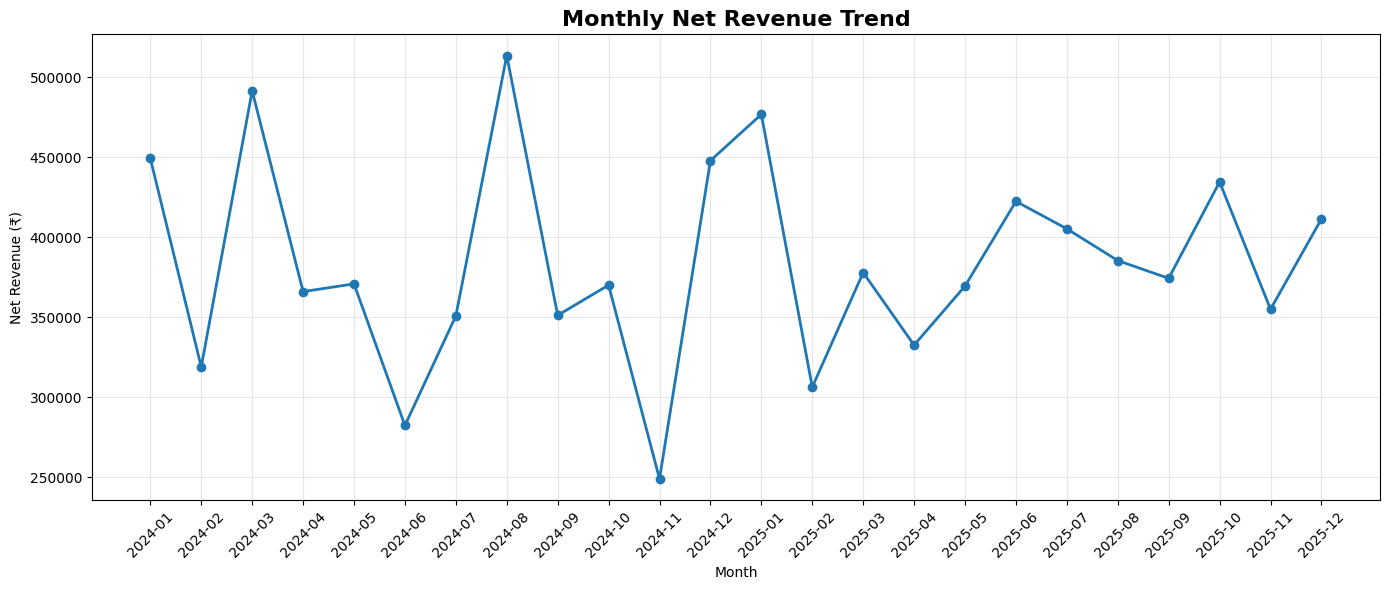

Visualization 1 created successfully.
Saved to: c:\Users\mehta\OneDrive\Week6_Final_Data_Analytics_Project\visualizations\visualization_01_monthly_revenue.png


In [29]:
# ============================================================
# STEP 27 — VISUALIZATION 1: MONTHLY REVENUE TREND
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_trend["Year_Month"],
    monthly_trend["Net_Revenue"],
    marker="o",
    linewidth=2
)

plt.title(
    "Monthly Net Revenue Trend",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Net Revenue (₹)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()

visualization_folder = PROJECT_ROOT / "visualizations"
visualization_folder.mkdir(parents=True, exist_ok=True)

chart_path = visualization_folder / "visualization_01_monthly_revenue.png"

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Visualization 1 created successfully.")
print(f"Saved to: {chart_path}")

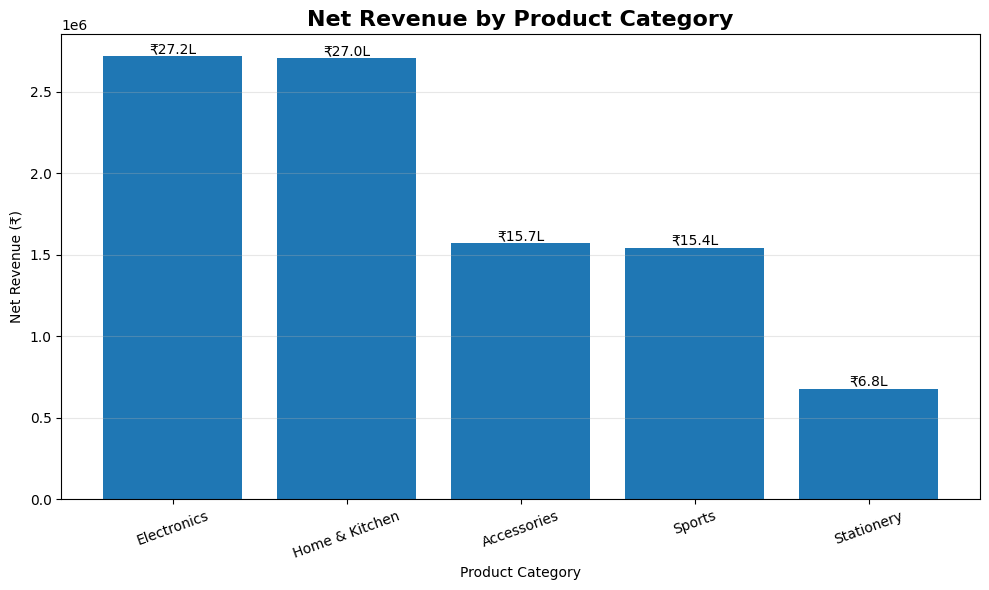

Visualization 2 created successfully.
Saved to: c:\Users\mehta\OneDrive\Week6_Final_Data_Analytics_Project\visualizations\visualization_02_revenue_by_category.png


In [30]:
# ============================================================
# STEP 28 — VISUALIZATION 2: REVENUE BY CATEGORY
# ============================================================

category_revenue = (
    cleaned_df.groupby("Category")["Net_Revenue"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    category_revenue.index,
    category_revenue.values
)

plt.title(
    "Net Revenue by Product Category",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Product Category")
plt.ylabel("Net Revenue (₹)")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)

# Add value labels
for bar, value in zip(bars, category_revenue.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"₹{value/100000:.1f}L",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()

chart_path = (
    visualization_folder /
    "visualization_02_revenue_by_category.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Visualization 2 created successfully.")
print(f"Saved to: {chart_path}")

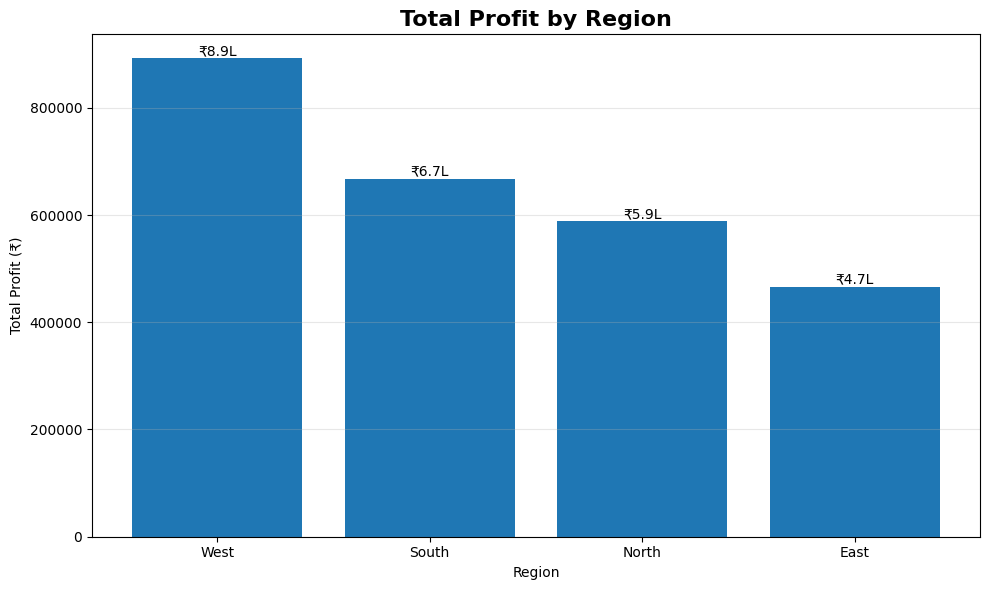

Visualization 3 created successfully.
Saved to: c:\Users\mehta\OneDrive\Week6_Final_Data_Analytics_Project\visualizations\visualization_03_profit_by_region.png


In [31]:
# ============================================================
# STEP 29 — VISUALIZATION 3: PROFIT BY REGION
# ============================================================

region_profit = (
    cleaned_df.groupby("Region")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    region_profit.index,
    region_profit.values
)

plt.title(
    "Total Profit by Region",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Region")
plt.ylabel("Total Profit (₹)")
plt.grid(axis="y", alpha=0.3)

# Add value labels
for bar, value in zip(bars, region_profit.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"₹{value/100000:.1f}L",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()

chart_path = (
    visualization_folder /
    "visualization_03_profit_by_region.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Visualization 3 created successfully.")
print(f"Saved to: {chart_path}")

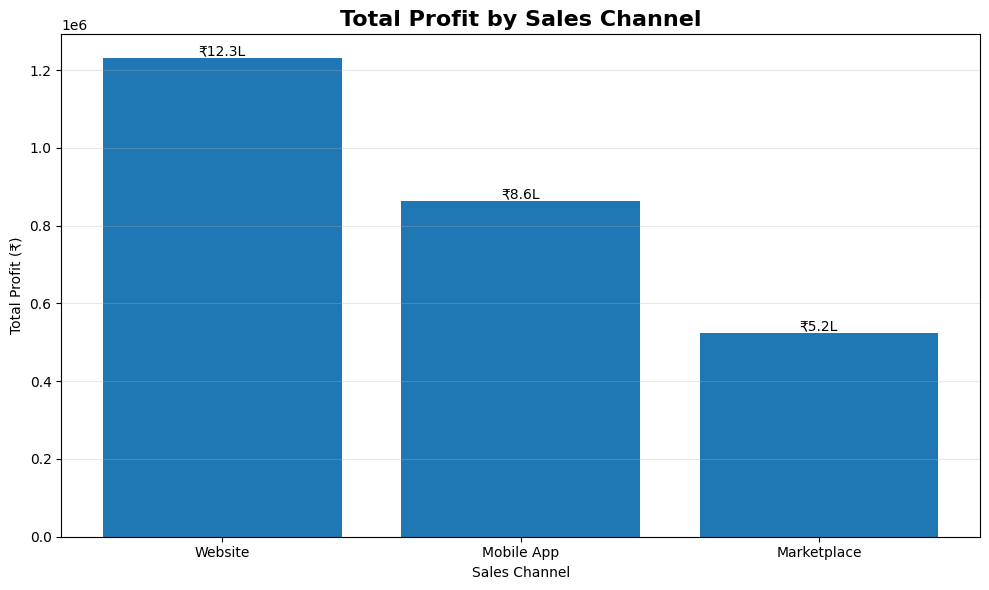

Visualization 4 created successfully.
Saved to: c:\Users\mehta\OneDrive\Week6_Final_Data_Analytics_Project\visualizations\visualization_04_profit_by_sales_channel.png


In [32]:
# ============================================================
# STEP 30 — VISUALIZATION 4: PROFIT BY SALES CHANNEL
# ============================================================

channel_profit = (
    cleaned_df.groupby("Sales_Channel")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    channel_profit.index,
    channel_profit.values
)

plt.title(
    "Total Profit by Sales Channel",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Sales Channel")
plt.ylabel("Total Profit (₹)")
plt.grid(axis="y", alpha=0.3)

# Add value labels
for bar, value in zip(bars, channel_profit.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"₹{value/100000:.1f}L",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()

chart_path = (
    visualization_folder /
    "visualization_04_profit_by_sales_channel.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Visualization 4 created successfully.")
print(f"Saved to: {chart_path}")

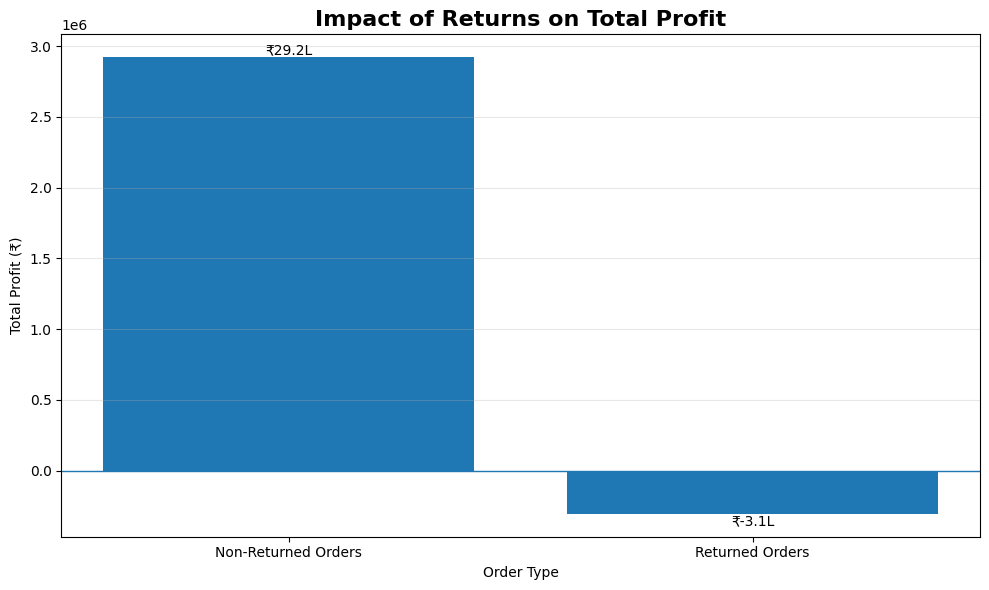

Visualization 5 created successfully.
Saved to: c:\Users\mehta\OneDrive\Week6_Final_Data_Analytics_Project\visualizations\visualization_05_return_impact_on_profit.png

Profit comparison:
Return_Flag
Non-Returned Orders    2922659.53
Returned Orders        -306683.47
Name: Profit, dtype: float64


In [33]:
# ============================================================
# STEP 31 — VISUALIZATION 5: RETURN IMPACT ON PROFIT
# ============================================================

return_profit = (
    cleaned_df.groupby("Return_Flag")["Profit"]
    .sum()
    .rename(index={
        False: "Non-Returned Orders",
        True: "Returned Orders"
    })
)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    return_profit.index,
    return_profit.values
)

plt.title(
    "Impact of Returns on Total Profit",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Order Type")
plt.ylabel("Total Profit (₹)")
plt.grid(axis="y", alpha=0.3)

# Add value labels
for bar, value in zip(bars, return_profit.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"₹{value/100000:.1f}L",
        ha="center",
        va="bottom" if value >= 0 else "top",
        fontsize=10
    )

plt.axhline(
    y=0,
    linewidth=1
)

plt.tight_layout()

chart_path = (
    visualization_folder /
    "visualization_05_return_impact_on_profit.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Visualization 5 created successfully.")
print(f"Saved to: {chart_path}")

print("\nProfit comparison:")
print(return_profit)

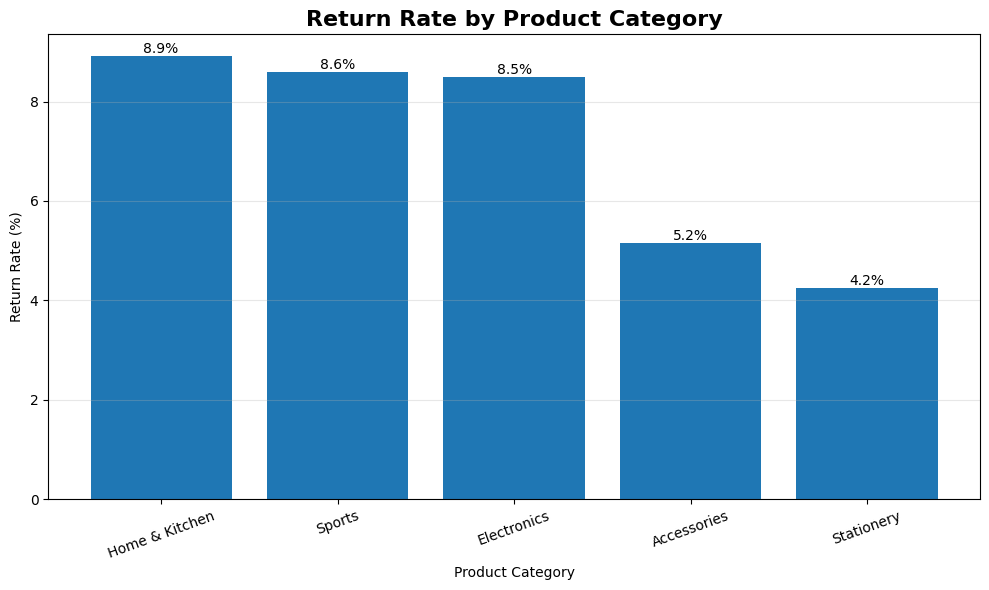

Visualization 6 created successfully.
Saved to: c:\Users\mehta\OneDrive\Week6_Final_Data_Analytics_Project\visualizations\visualization_06_return_rate_by_category.png

Return rate by category:
Category
Home & Kitchen    8.91
Sports            8.59
Electronics       8.50
Accessories       5.16
Stationery        4.25
Name: Return_Flag, dtype: float64


In [34]:
# ============================================================
# STEP 32 — VISUALIZATION 6: RETURN RATE BY CATEGORY
# ============================================================

category_return_rate = (
    cleaned_df.groupby("Category")["Return_Flag"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    category_return_rate.index,
    category_return_rate.values
)

plt.title(
    "Return Rate by Product Category",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Product Category")
plt.ylabel("Return Rate (%)")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)

# Add percentage labels
for bar, value in zip(
    bars,
    category_return_rate.values
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()

chart_path = (
    visualization_folder /
    "visualization_06_return_rate_by_category.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Visualization 6 created successfully.")
print(f"Saved to: {chart_path}")

print("\nReturn rate by category:")
print(category_return_rate.round(2))

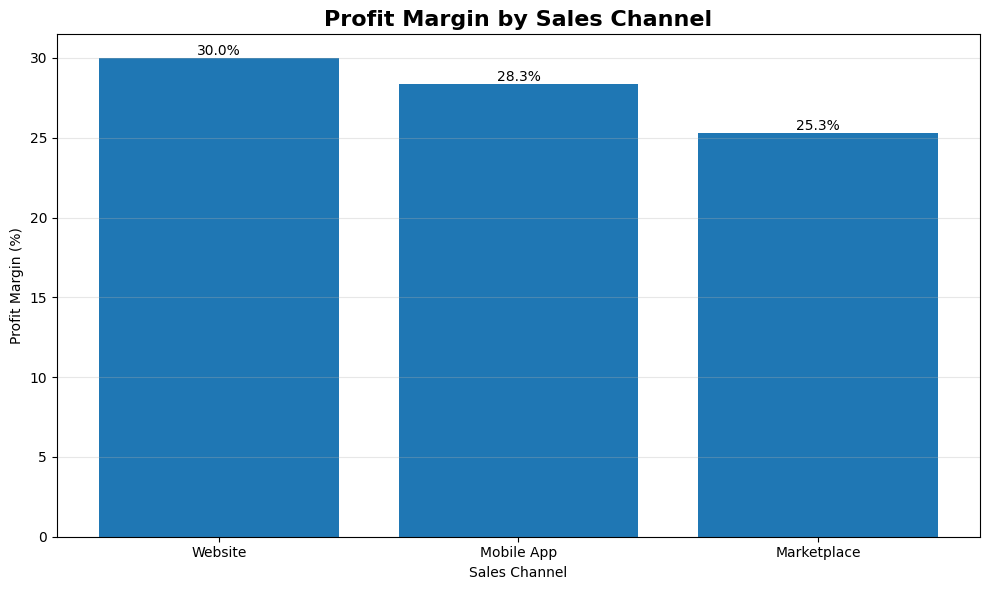

Visualization 7 created successfully.
Saved to: c:\Users\mehta\OneDrive\Week6_Final_Data_Analytics_Project\visualizations\visualization_07_profit_margin_by_sales_channel.png

Profit margin by sales channel:
Sales_Channel
Website        29.98
Mobile App     28.35
Marketplace    25.29
Name: Profit_Margin, dtype: float64


In [35]:
# ============================================================
# STEP 33 — VISUALIZATION 7: PROFIT MARGIN BY SALES CHANNEL
# ============================================================

channel_margin = (
    cleaned_df.groupby("Sales_Channel")
    .agg(
        Net_Revenue=("Net_Revenue", "sum"),
        Profit=("Profit", "sum")
    )
)

channel_margin["Profit_Margin"] = (
    channel_margin["Profit"] /
    channel_margin["Net_Revenue"]
) * 100

channel_margin = channel_margin["Profit_Margin"].sort_values(
    ascending=False
)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    channel_margin.index,
    channel_margin.values
)

plt.title(
    "Profit Margin by Sales Channel",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Sales Channel")
plt.ylabel("Profit Margin (%)")
plt.grid(axis="y", alpha=0.3)

# Add percentage labels
for bar, value in zip(
    bars,
    channel_margin.values
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()

chart_path = (
    visualization_folder /
    "visualization_07_profit_margin_by_sales_channel.png"
)

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Visualization 7 created successfully.")
print(f"Saved to: {chart_path}")

print("\nProfit margin by sales channel:")
print(channel_margin.round(2))